In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [3]:
#loading the data in dataframe 
df = pd.read_csv("/Users/sunilverma/Downloads/MegaMart_sales.csv") 
df.head()

,Order ID,Product Name,Discount,Sales,Profit,Quantity,Category,Sub-Category
0,AZ-2011-1029887,"Novimex Color Coded Labels, 5000 Label Set",0.0,26,7,2,Office Supplies,Labels
1,AZ-2011-107716,"Deflect-O Door Stop, Erganomic",0.0,85,15,2,Furniture,Furnishings
2,AZ-2011-1087704,"Belkin Flash Drive, Bluetooth",0.0,294,109,7,Technology,Accessories
3,AZ-2011-1372644,"Panasonic Printer, Durable",0.0,800,168,3,Technology,Machines
4,AZ-2011-1362199,"Sanford Pens, Fluorescent",0.5,25,-11,4,Office Supplies,Art


### Data Wrangling 

In [4]:
#cheking the demographics of the data
df.shape

(59, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      59 non-null     object 
 1   Product Name  59 non-null     object 
 2   Discount      59 non-null     float64
 3   Sales         59 non-null     int64  
 4   Profit        59 non-null     int64  
 5   Quantity      59 non-null     int64  
 6   Category      59 non-null     object 
 7   Sub-Category  59 non-null     object 
dtypes: float64(1), int64(3), object(4)
memory usage: 3.8+ KB


In [6]:
df.describe()

,Discount,Sales,Profit,Quantity
count,59.000000,59.000000,59.000000,59.000000
mean,0.094915,300.830508,62.355932,3.898305
std,0.184226,403.498158,132.271894,2.233714
min,0.000000,10.000000,-98.000000,1.000000
25%,0.000000,38.500000,3.000000,2.000000
50%,0.000000,98.000000,15.000000,3.000000
75%,0.100000,403.000000,104.000000,5.000000
max,0.600000,1908.000000,820.000000,12.000000


In [8]:
cat_cols = df.select_dtypes(include= 'object')
cat_cols

,Order ID,Product Name,Category,Sub-Category
0,AZ-2011-1029887,"Novimex Color Coded Labels, 5000 Label Set",Office Supplies,Labels
1,AZ-2011-107716,"Deflect-O Door Stop, Erganomic",Furniture,Furnishings
2,AZ-2011-1087704,"Belkin Flash Drive, Bluetooth",Technology,Accessories
3,AZ-2011-1372644,"Panasonic Printer, Durable",Technology,Machines
4,AZ-2011-1362199,"Sanford Pens, Fluorescent",Office Supplies,Art
5,AZ-2011-1114253,"Tenex Stacking Tray, Black",Furniture,Furnishings
6,AZ-2011-1116129,"Avery Binding Machine, Durable",Office Supplies,Binders
7,AZ-2011-1137571,"Stiletto Letter Opener, Easy Grip",Office Supplies,Supplies
8,AZ-2011-1174243,"Nokia Audio Dock, with Caller ID",Technology,Phones
9,AZ-2011-122598,"Avery Removable Labels, Alphabetical",Office Supplies,Labels


### Visualizing the data 

In [10]:
#separating the numrical and categorical columns
num_cols = df.select_dtypes(include= ['int64', 'float64'])
num_cols.head()

,Discount,Sales,Profit,Quantity
0,0.0,26,7,2
1,0.0,85,15,2
2,0.0,294,109,7
3,0.0,800,168,3
4,0.5,25,-11,4


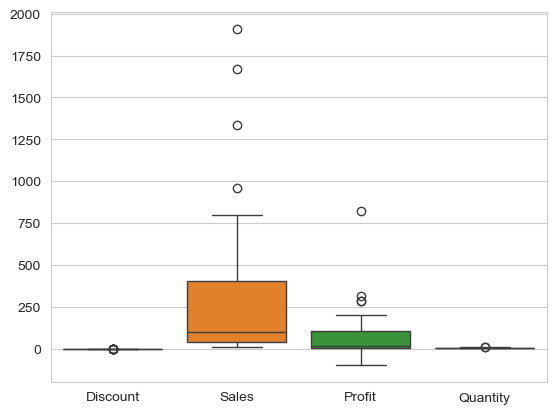

In [15]:
#checking the outliers in the data 
sns.set_style('whitegrid')
sns.boxplot(df) 
plt.show()

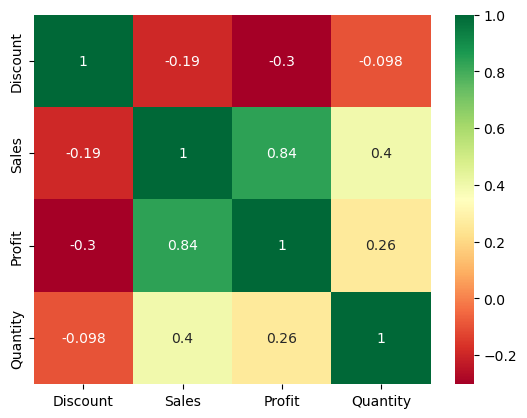

In [12]:
#check the correlation in numrical coloumn 
num_corr_df = num_cols.corr() 
sns.heatmap(num_corr_df,annot= True, cmap = 'RdYlGn') 
plt.show()

<Figure size 1000x800 with 0 Axes>

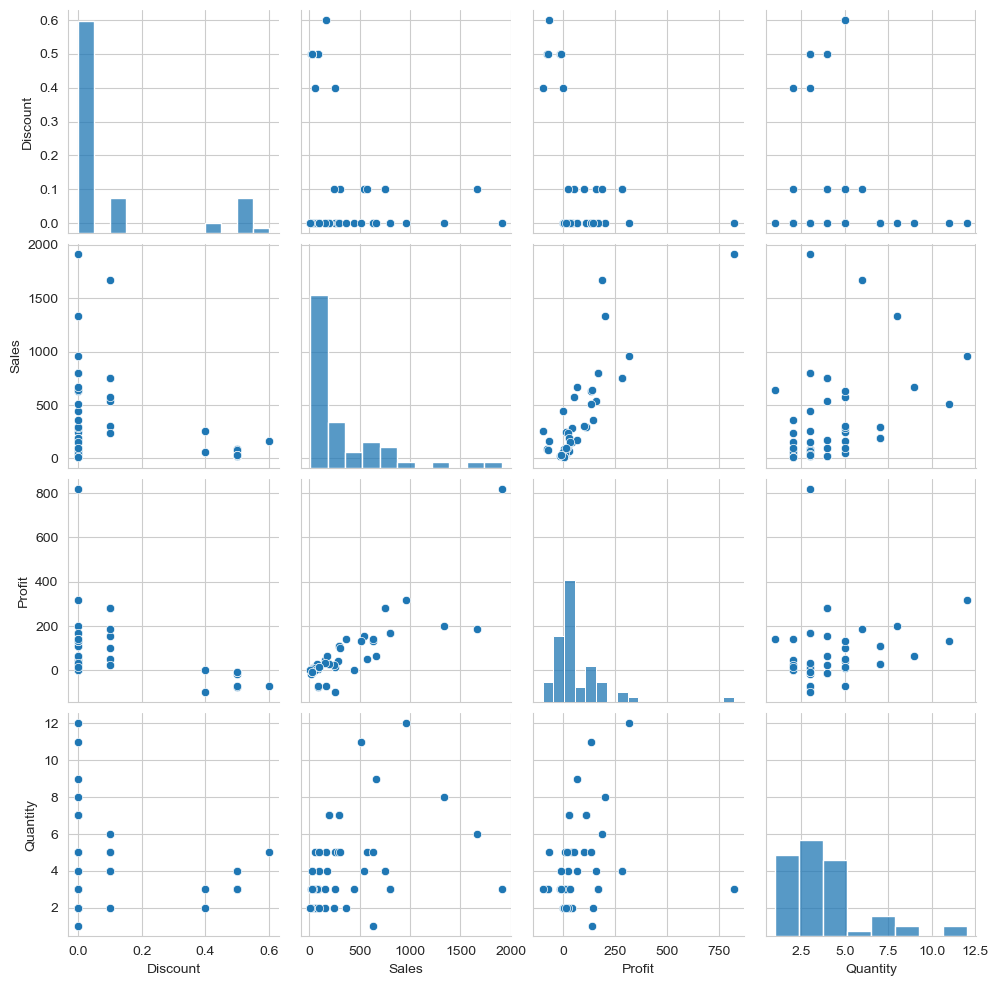

In [17]:
plt.figure(figsize=(10,8))
sns.pairplot(df, diag_kind= 'auto')  
plt.show()

### EDA 

In [18]:
df.head()

,Order ID,Product Name,Discount,Sales,Profit,Quantity,Category,Sub-Category
0,AZ-2011-1029887,"Novimex Color Coded Labels, 5000 Label Set",0.0,26,7,2,Office Supplies,Labels
1,AZ-2011-107716,"Deflect-O Door Stop, Erganomic",0.0,85,15,2,Furniture,Furnishings
2,AZ-2011-1087704,"Belkin Flash Drive, Bluetooth",0.0,294,109,7,Technology,Accessories
3,AZ-2011-1372644,"Panasonic Printer, Durable",0.0,800,168,3,Technology,Machines
4,AZ-2011-1362199,"Sanford Pens, Fluorescent",0.5,25,-11,4,Office Supplies,Art


In [22]:
#grouping the data and visualizing the data into different groups 
sales_n_profit = df.groupby(by = ['Category', 'Sub-Category'])['Profit'].sum().sort_values(ascending= False)
sales_n_profit

Category         Sub-Category
Technology       Phones          1618
Office Supplies  Storage          468
Technology       Machines         336
Furniture        Bookcases        288
Technology       Accessories      284
Office Supplies  Appliances       229
                 Art              228
                 Supplies         103
Furniture        Furnishings       74
Office Supplies  Binders           44
                 Labels            30
                 Envelopes         16
                 Fasteners         10
Technology       Copiers            0
Furniture        Chairs           -49
Name: Profit, dtype: int64

In [28]:
def extract_order_id(order_id):
    order_no = order_id.split('-')[2] 
    return order_no

In [29]:
df['Order ID'] = df['Order ID'].apply(extract_order_id) 
df.head()

AttributeError: 'list' object has no attribute 'split'

In [31]:
n = 5  
for i in range(n): 
    for j in range(n): 
        print('*', end=' ')
    print()

* * * * * 
* * * * * 
* * * * * 
* * * * * 
* * * * * 


In [32]:
n = 5

for i in range(n):
    # print spaces
    for j in range(n - i - 1):
        print(' ', end=' ')
        
    # print stars
    for k in range(2 * i + 1):
        print('*', end=' ')
        
    print()

        * 
      * * * 
    * * * * * 
  * * * * * * * 
* * * * * * * * * 
